# Evaluation Metrics Pipeline

This notebook runs an end-to-end evaluation workflow for two core RAG strategies and an optional ablation suite:

- **Strategy A**: Hybrid Retrieval (BM25 + Vector)
- **Strategy B**: Hybrid Retrieval + Rerank

It generates predictions from the latest QA pipeline, evaluates them against ground truth, and provides side-by-side comparisons plus experiment conclusions.

## Ablation
This notebook also provide ablation test by setting retrieval/rerank/KG configurations
across all 8 combinations of the following switches:

| Switch | Values |
|---|---|
| `use_vector` (BM25-only vs BM25+Vector) | `false` / `true` |
| `enable_rerank` | `false` / `true` |
| `enable_kg` (Knowledge Graph boost) | `false` / `true` |

The 8 experiment configurations are:

| Experiment | use_vector | enable_rerank | enable_kg |
|---|---|---|---|
| `BM25` | false | false | false |
| `BM25_plus_KG` | false | false | true |
| `BM25_plus_Rerank` | false | true | false |
| `BM25_plus_Rerank_plus_KG` | false | true | true |
| `Hybrid` | true | false | false |
| `Hybrid_plus_KG` | true | false | true |
| `Hybrid_plus_Rerank` | true | true | false |
| `Hybrid_plus_Rerank_plus_KG` | true | true | true |

## Metrics
- Retrieval: Recall@K, Precision@K, MRR@K, nDCG@K, MAP@K
- Generation: Exact Match, Token F1, ROUGE-L
- Citation (if available): Citation hit rate

In [81]:
from pathlib import Path
import subprocess
import json

try:
    import pandas as pd
except Exception:
    pd = None

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for cur in [p] + list(p.parents):
        if (cur / "config.py").exists() and (cur / "scripts").exists() and (cur / "data").exists():
            return cur
    raise RuntimeError("Cannot find repository root")

ROOT = find_repo_root(Path.cwd())

def display_path(path: Path | str) -> str:
    p = Path(path).resolve() if not isinstance(path, Path) else path.resolve()
    root = ROOT.resolve()
    try:
        rel = p.relative_to(root)
        return ROOT.name if str(rel) == "." else f"{ROOT.name}/{rel.as_posix()}"
    except Exception:
        return str(path)

def cmd_path(path: Path | str) -> str:
    p = Path(path) if not isinstance(path, Path) else path
    try:
        return p.resolve().relative_to(ROOT.resolve()).as_posix()
    except Exception:
        return str(path)

print("Repository root:", display_path(ROOT))

Repository root: qa_agent_legal_tax


## 1) Install dependencies

Run once if needed.

In [82]:
import sys

# Set to True to install required dependencies before running the evaluation pipeline.
INSTALL_DEPS = True

if INSTALL_DEPS:
    def run(cmd):
        normalized_cmd = list(cmd)
        if normalized_cmd and normalized_cmd[0] == "python":
            normalized_cmd[0] = sys.executable
        subprocess.run(
            normalized_cmd,
            cwd=ROOT,
            check=True,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
        )

    MINIMAL_PACKAGES = [
        "pip==26.0.1",
        "setuptools==82.0.1",
        "wheel==0.46.3",
        "python-dotenv>=1.0.0",
        "pyyaml==6.0.1",
        "openai==1.66.0",
        "google-genai==1.66.0",
        "pydantic>=2.9.0,<3.0.0",
        "numpy>=1.26.4,<2.0",
        "pandas>=2.2.2,<2.3",
        "python-dateutil>=2.8.2",
        "rouge-score>=0.1.2",
        "rank-bm25>=0.2.2",
        "cohere>=5.11.0",
    ]

    run([
        sys.executable,
        "-m",
        "pip",
        "install",
        "--no-cache-dir",
        "--prefer-binary",
        "--upgrade-strategy",
        "only-if-needed",
        *MINIMAL_PACKAGES,
    ])

    print("All required packages have been installed/updated successfully.")

All required packages have been installed/updated successfully.


## 2) Configure input/output paths

In [83]:
GT = ROOT / "data" / "qa_pairs" / "eval_ground_truth.jsonl"
if not GT.exists():
    print(f"Ground truth file not found, generating: {display_path(GT)}")
    gen_script = ROOT / "scripts" / "eval" / "generate_eval_ground_truth.py"
    if not gen_script.exists():
        raise FileNotFoundError(f"Ground truth generator script not found: {display_path(gen_script)}")

    run([
        "python", str(gen_script.relative_to(ROOT)), "--out", str(GT.relative_to(ROOT))
    ])

    if not GT.exists():
        raise FileNotFoundError(f"Failed to generate ground truth file: {display_path(GT)}")

PRED_HYBRID = ROOT / "outputs" / "preds_hybrid.jsonl"
PRED_HYBRID_RERANK = ROOT / "outputs" / "preds_hybrid_rerank.jsonl"

EVAL_HYBRID = ROOT / "outputs" / "eval_hybrid.json"
EVAL_HYBRID_RERANK = ROOT / "outputs" / "eval_hybrid_rerank.json"

EVAL_GEN_HYBRID = ROOT / "outputs" / "eval_gen_hybrid.json"
EVAL_GEN_HYBRID_RERANK = ROOT / "outputs" / "eval_gen_hybrid_rerank.json"

print("Ground truth:", display_path(GT))

Ground truth: qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl


## 3) Generate predictions for both RAG strategies

In [84]:
import os
from dotenv import load_dotenv

# Re-read .env every time this cell runs, overriding any stale values
load_dotenv(ROOT / ".env", override=True)

for name in ["OPENAI_API_KEY", "GOOGLE_API_KEY"]:
    val = os.getenv(name)
    if val:
        print(f"[debug] {name}=****{val[-4:]}")
    else:
        print(f"[debug] {name}=<missing>")

# Clean stale prediction and evaluation outputs before generating new predictions
outputs_dir = ROOT / "outputs"
outputs_dir.mkdir(parents=True, exist_ok=True)
for pattern in ("preds_hybrid*.jsonl", "eval_hybrid*.json", "eval_gen_hybrid*.json", "run_snapshot_*.json"):
    for stale_file in outputs_dir.glob(pattern):
        stale_file.unlink(missing_ok=True)
        print(f"Removed stale file: {display_path(stale_file)}")
print("Cleaned stale output files.")

print(f"\nTotal samples to evaluate: {sum(1 for _ in open(GT, 'r', encoding='utf-8'))}, estimated time: {sum(1 for _ in open(GT, 'r', encoding='utf-8')) * 5 / 60:.2f} minutes (assuming ~5s per sample)")
print("Starting evaluation pipeline for Strategy A: Hybrid Retrieval (BM25 + Vector)...")
# Strategy A: Hybrid Retrieval (BM25 + Vector)
run([
    "python", "scripts/eval/run_eval_benchmark.py",
    "--gt", cmd_path(GT),
    "--out", cmd_path(PRED_HYBRID),
    "--enable-rerank", "false"
])

print("Starting evaluation pipeline for Strategy B: Hybrid Retrieval + Rerank...")
# Strategy B: Hybrid Retrieval + Rerank
run([
    "python", "scripts/eval/run_eval_benchmark.py",
    "--gt", cmd_path(GT),
    "--out", cmd_path(PRED_HYBRID_RERANK),
    "--enable-rerank", "true"
])

print("Evaluation metrics completed.")

[debug] OPENAI_API_KEY=****here
[debug] GOOGLE_API_KEY=****Jaoo
Removed stale file: qa_agent_legal_tax/outputs/preds_hybrid.jsonl
Removed stale file: qa_agent_legal_tax/outputs/preds_hybrid_rerank.jsonl
Removed stale file: qa_agent_legal_tax/outputs/eval_hybrid.json
Removed stale file: qa_agent_legal_tax/outputs/eval_hybrid_rerank.json
Removed stale file: qa_agent_legal_tax/outputs/eval_gen_hybrid.json
Removed stale file: qa_agent_legal_tax/outputs/eval_gen_hybrid_rerank.json
Removed stale file: qa_agent_legal_tax/outputs/run_snapshot_20260320_234613.json
Removed stale file: qa_agent_legal_tax/outputs/run_snapshot_20260320_235058.json
Cleaned stale output files.

Total samples to evaluate: 32, estimated time: 2.67 minutes (assuming ~5s per sample)
Starting evaluation pipeline for Strategy A: Hybrid Retrieval (BM25 + Vector)...
Starting evaluation pipeline for Strategy B: Hybrid Retrieval + Rerank...
Evaluation metrics completed.


## 4) Compute evaluation metrics (retrieval + generation)

In [85]:
def run_quiet(cmd):
    normalized_cmd = list(cmd)
    if normalized_cmd and normalized_cmd[0] == "python":
        normalized_cmd[0] = sys.executable
    subprocess.run(
        normalized_cmd,
        cwd=ROOT,
        check=True,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    )

run_quiet([
    "python", "scripts/eval/evaluate_predictions.py",
    "--gt", cmd_path(GT),
    "--pred", cmd_path(PRED_HYBRID),
    "--k", "5",
    "--out", cmd_path(EVAL_HYBRID)
])

run_quiet([
    "python", "scripts/eval/evaluate_predictions.py",
    "--gt", cmd_path(GT),
    "--pred", cmd_path(PRED_HYBRID_RERANK),
    "--k", "5",
    "--out", cmd_path(EVAL_HYBRID_RERANK)
])

print("Evaluation predictions completed.")

Evaluation predictions completed.


## 5) Generation-only metrics

In [86]:
run_quiet([
    "python", "scripts/eval/evaluate_generation.py",
    "--gt", cmd_path(GT),
    "--pred", cmd_path(PRED_HYBRID),
    "--out", cmd_path(EVAL_GEN_HYBRID)
])

run_quiet([
    "python", "scripts/eval/evaluate_generation.py",
    "--gt", cmd_path(GT),
    "--pred", cmd_path(PRED_HYBRID_RERANK),
    "--out", cmd_path(EVAL_GEN_HYBRID_RERANK)
])
print("Evaluation generation completed.")

Evaluation generation completed.


## 6) Load and compare results

In [87]:
def load_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))

hybrid = load_json(EVAL_HYBRID)
hybrid_rerank = load_json(EVAL_HYBRID_RERANK)

# print("Hybrid:")
# print(json.dumps(hybrid, indent=2, ensure_ascii=False))
# print("\nHybrid + Rerank:")
# print(json.dumps(hybrid_rerank, indent=2, ensure_ascii=False))

Metrics table:


,strategy,recall@5,precision@5,ndcg@5,mrr@5,map@5,gen_exact_match,gen_token_f1,gen_rougeL_f1,gen_citation_hit_rate
0,Hybrid,0.796875,0.21875,0.641088,0.645312,0.580208,0.0,0.083300,0.073048,0.515625
1,Hybrid+Rerank,0.895833,0.25625,0.844727,0.886458,0.806771,0.0,0.074046,0.065514,0.453125


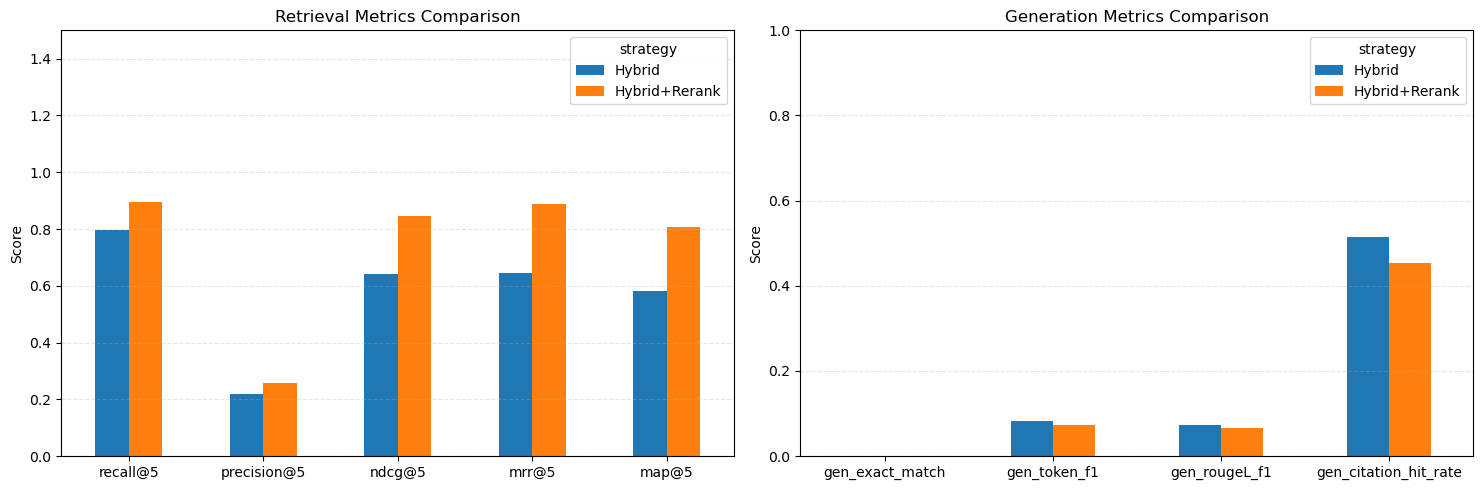

,delta (Rerank - Hybrid)
mrr@5,0.241146
map@5,0.226562
ndcg@5,0.203639
recall@5,0.098958
precision@5,0.037500
gen_exact_match,0.000000
gen_rougeL_f1,-0.007534
gen_token_f1,-0.009254
gen_citation_hit_rate,-0.062500


In [88]:
def flatten_eval(label, obj):
    row = {"strategy": label}
    row.update(obj.get("retrieval", {}))
    gen = obj.get("generation", {})
    row.update({f"gen_{k}": v for k, v in gen.items()})
    return row

rows = [
    flatten_eval("Hybrid", hybrid),
    flatten_eval("Hybrid+Rerank", hybrid_rerank),
]

if pd is not None:
    df_metrics = pd.DataFrame(rows)
    print("Metrics table:")
    display(df_metrics)

    import matplotlib.pyplot as plt

    df_plot = pd.DataFrame(rows).set_index("strategy")

    retrieval_cols = [c for c in ["recall@5", "precision@5", "ndcg@5", "mrr@5", "map@5"] if c in df_plot.columns]
    gen_cols = [c for c in ["gen_exact_match", "gen_token_f1", "gen_rougeL_f1", "gen_citation_hit_rate"] if c in df_plot.columns]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    if retrieval_cols:
        df_plot[retrieval_cols].T.plot(kind="bar", ax=axes[0], rot=0)
        axes[0].set_title("Retrieval Metrics Comparison")
        axes[0].set_ylim(0, 1.5)
        axes[0].set_ylabel("Score")
        axes[0].grid(axis="y", linestyle="--", alpha=0.3)

    if gen_cols:
        df_plot[gen_cols].T.plot(kind="bar", ax=axes[1], rot=0)
        axes[1].set_title("Generation Metrics Comparison")
        axes[1].set_ylim(0, 1)
        axes[1].set_ylabel("Score")
        axes[1].grid(axis="y", linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Show delta: Hybrid+Rerank minus Hybrid
    if "Hybrid" in df_plot.index and "Hybrid+Rerank" in df_plot.index:
        delta = (df_plot.loc["Hybrid+Rerank"] - df_plot.loc["Hybrid"]).sort_values(ascending=False)
        display(delta.to_frame("delta (Rerank - Hybrid)"))
else:
    print("pandas not available, skipping plot.")



## 6.1) Ablation: retrieval/rerank/KG settings

This experiment runs settings across three switches and compares metrics side by side:

- Vector retrieval: on/off
- Rerank: on/off
- Knowledge Graph boost (KG): on/off

Use this to diagnose whether score changes come from retrieval quality, reranking, or KG boosting.

In [89]:
import os
import time
from pathlib import Path
from dotenv import load_dotenv

# Ensure latest API keys/settings are loaded for subprocesses.
load_dotenv(ROOT / ".env", override=True)

AB_OUT_DIR = ROOT / "outputs" / "ablation"
AB_OUT_DIR.mkdir(parents=True, exist_ok=True)

# Set to True for fast, stable retrieval ablation (skips LLM generation).
AB_RETRIEVAL_ONLY = False

# Clean stale ablation artifacts before each run to avoid mixing legacy/current results.
for pattern in ("eval_*.json", "preds_*.jsonl", "run_snapshot_*.json"):
    for stale_file in AB_OUT_DIR.glob(pattern):
        stale_file.unlink(missing_ok=True)
print(f"Cleaned stale ablation files in: {display_path(AB_OUT_DIR)}")

experiments = [
    {"name": "BM25", "use_vector": "false", "enable_rerank": "false", "enable_kg": "false"},
    {"name": "BM25_KG", "use_vector": "false", "enable_rerank": "false", "enable_kg": "true"},
    {"name": "BM25_Rerank", "use_vector": "false", "enable_rerank": "true", "enable_kg": "false"},
    {"name": "BM25_Rerank_KG", "use_vector": "false", "enable_rerank": "true", "enable_kg": "true"},
    {"name": "Hybrid", "use_vector": "true", "enable_rerank": "false", "enable_kg": "false"},
    {"name": "Hybrid_KG", "use_vector": "true", "enable_rerank": "false", "enable_kg": "true"},
    {"name": "Hybrid_Rerank", "use_vector": "true", "enable_rerank": "true", "enable_kg": "false"},
    {"name": "Hybrid_Rerank_KG", "use_vector": "true", "enable_rerank": "true", "enable_kg": "true"},
]

def _format_cmd_for_log(cmd):
    formatted = []
    for token in cmd:
        text = str(token)
        p = Path(text)
        if p.is_absolute():
            formatted.append(display_path(p))
        else:
            formatted.append(text)
    return formatted


def run_with_env(cmd, env_overrides, retries=2, retry_wait_sec=3):
    env = os.environ.copy()
    env.update(env_overrides)

    cmd_for_log = _format_cmd_for_log(cmd)

    last_error = None
    for attempt in range(1, retries + 2):
        print("\n$", " ".join(cmd_for_log), "\n  env:", env_overrides, f"\n  attempt: {attempt}/{retries + 1}")
        try:
            subprocess.run(cmd, cwd=ROOT, check=True, env=env)
            return
        except subprocess.CalledProcessError as e:
            last_error = e
            if attempt <= retries:
                print(f"[WARN] Command failed (exit={e.returncode}). Retrying in {retry_wait_sec}s...")
                time.sleep(retry_wait_sec)
            else:
                raise

    if last_error is not None:
        raise last_error

ab_rows = []
failed_experiments = []

total_samples = sum(1 for _ in open(GT, 'r', encoding='utf-8'))
estimated_time = total_samples * 5 / 60 * len(experiments)
print(f"\nStarting ablation experiments: total samples: {total_samples}, total experiments: {len(experiments)}, estimated time: {estimated_time:.2f} minutes...")

for exp in experiments:
    pred_path = AB_OUT_DIR / f"preds_{exp['name']}.jsonl"
    eval_path = AB_OUT_DIR / f"eval_{exp['name']}.json"
    
    print(f"\n=== Running experiment: {exp['name']} ({experiments.index(exp) + 1}/{len(experiments)}) ===")
    env_overrides = {
        "USE_BM25": "true",
        "USE_VECTOR": exp["use_vector"],
        "ENABLE_RERANK": exp["enable_rerank"],
        "ENABLE_KG": exp["enable_kg"],
    }

    benchmark_cmd = [
        sys.executable,
        "scripts/eval/run_eval_benchmark.py",
        "--gt",
        str(GT),
        "--out",
        str(pred_path),
        "--enable-rerank",
        exp["enable_rerank"],
    ]
    if AB_RETRIEVAL_ONLY:
        benchmark_cmd.extend(["--retrieval-only", "true", "--top-k", "5"])

    try:
        run_with_env(
            benchmark_cmd,
            env_overrides,
        )

        run_with_env(
            [
                sys.executable,
                "scripts/eval/evaluate_predictions.py",
                "--gt",
                str(GT),
                "--pred",
                str(pred_path),
                "--k",
                "5",
                "--out",
                str(eval_path),
            ],
            env_overrides,
        )
    except subprocess.CalledProcessError as e:
        failed_experiments.append({
            "experiment": exp["name"],
            "error": f"Command failed with exit code {e.returncode}",
            "use_vector": exp["use_vector"],
            "enable_rerank": exp["enable_rerank"],
            "enable_kg": exp["enable_kg"],
        })
        print(f"[ERROR] Skip experiment {exp['name']} due to subprocess failure.")
        continue

    if not eval_path.exists():
        failed_experiments.append({
            "experiment": exp["name"],
            "error": "Evaluation output JSON was not generated",
            "use_vector": exp["use_vector"],
            "enable_rerank": exp["enable_rerank"],
            "enable_kg": exp["enable_kg"],
        })
        print(f"[ERROR] Skip experiment {exp['name']}: missing eval file {eval_path}")
        continue

    report = json.loads(eval_path.read_text(encoding="utf-8"))
    row = {
        "experiment": exp["name"],
        "use_vector": exp["use_vector"],
        "enable_rerank": exp["enable_rerank"],
        "enable_kg": exp["enable_kg"],
    }
    row.update(report.get("retrieval", {}))
    row.update({f"gen_{k}": v for k, v in report.get("generation", {}).items()})
    ab_rows.append(row)

if pd is not None:
    if ab_rows:
        df_ab = pd.DataFrame(ab_rows)
        display(df_ab)

        # Pairwise comparison: KG on - KG off under the same (vector, rerank) setting
        compare_cols = [
            "recall@5",
            "precision@5",
            "ndcg@5",
            "mrr@5",
            "map@5",
            "gen_exact_match",
            "gen_token_f1",
            "gen_rougeL_f1",
            "gen_citation_hit_rate",
        ]
        compare_cols = [c for c in compare_cols if c in df_ab.columns]

        pairs = []
        for use_vector in ["false", "true"]:
            for enable_rerank in ["false", "true"]:
                base = df_ab[
                    (df_ab["use_vector"] == use_vector)
                    & (df_ab["enable_rerank"] == enable_rerank)
                    & (df_ab["enable_kg"] == "false")
                ]
                kg = df_ab[
                    (df_ab["use_vector"] == use_vector)
                    & (df_ab["enable_rerank"] == enable_rerank)
                    & (df_ab["enable_kg"] == "true")
                ]
                if base.empty or kg.empty:
                    continue

                base_row = base.iloc[0]
                kg_row = kg.iloc[0]
                delta = {
                    "setting": f"vector={use_vector}, rerank={enable_rerank}",
                    "base_experiment": base_row["experiment"],
                    "kg_experiment": kg_row["experiment"],
                }
                for c in compare_cols:
                    delta[f"delta_{c}"] = float(kg_row[c]) - float(base_row[c])
                pairs.append(delta)

        if pairs:
            df_kg_delta = pd.DataFrame(pairs)
            print("KG impact summary (KG on - KG off):")
            display(df_kg_delta)
        else:
            print("No valid KG on/off pairs found for comparison.")
    else:
        print("No successful ablation runs to summarize.")

    if failed_experiments:
        print("\nFailed experiments:")
        display(pd.DataFrame(failed_experiments))
else:
    print(json.dumps(ab_rows, indent=2, ensure_ascii=False))
    if failed_experiments:
        print("\nFailed experiments:")
        print(json.dumps(failed_experiments, indent=2, ensure_ascii=False))

Cleaned stale ablation files in: qa_agent_legal_tax/outputs/ablation

Starting ablation experiments: total samples: 32, total experiments: 8, estimated time: 21.33 minutes...

=== Running experiment: BM25 (1/8) ===

$ /opt/anaconda3/bin/python scripts/eval/run_eval_benchmark.py --gt qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --out qa_agent_legal_tax/outputs/ablation/preds_BM25.jsonl --enable-rerank false 
  env: {'USE_BM25': 'true', 'USE_VECTOR': 'false', 'ENABLE_RERANK': 'false', 'ENABLE_KG': 'false'} 
  attempt: 1/3
QAAgent.__init__ signature: (self, retriever, llm_service, validator, config: Dict)
cfg_dict keys (63): ['ACTS_CHUNKED_DIR', 'ACTS_CSV', 'ACTS_HTML_DIR', 'ACTS_MD_DIR', 'BM25_B', 'BM25_K1', 'CHUNK_OVERLAP', 'CHUNK_SIZE', 'COHERE_API_KEY', 'COHERE_RERANK_MODEL', 'CONFIDENCE_CITATION_WEIGHT', 'CONFIDENCE_CONSISTENCY_WEIGHT', 'CONFIDENCE_MAX_EVIDENCE_SENTENCES', 'CONFIDENCE_RETRIEVAL_WEIGHT', 'CONFIDENCE_SENTENCE_SUPPORT_THRESHOLD', 'DATA_DIR', 'DEBUG', 'DOCS_D

Batch embedding hit Gemini rate/quota limit (attempt 1/10, mode=exp-backoff, tpm=False). Sleeping 1.0s before retry.
Batch embedding hit Gemini rate/quota limit (attempt 2/10, mode=exp-backoff, tpm=False). Sleeping 2.0s before retry.
Batch embedding hit Gemini rate/quota limit (attempt 3/10, mode=exp-backoff, tpm=False). Sleeping 4.0s before retry.
Batch embedding hit Gemini rate/quota limit (attempt 4/10, mode=exp-backoff, tpm=False). Sleeping 8.0s before retry.


Saved predictions: qa_agent_legal_tax/outputs/ablation/preds_Hybrid.jsonl (n=32)
[snapshot] Saved run config snapshot: qa_agent_legal_tax/outputs/ablation/run_snapshot_20260321_012549.json

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred qa_agent_legal_tax/outputs/ablation/preds_Hybrid.jsonl --k 5 --out qa_agent_legal_tax/outputs/ablation/eval_Hybrid.json 
  env: {'USE_BM25': 'true', 'USE_VECTOR': 'true', 'ENABLE_RERANK': 'false', 'ENABLE_KG': 'false'} 
  attempt: 1/3
{
  "retrieval": {
    "recall@5": 0.8802083333333334,
    "precision@5": 0.23750000000000002,
    "ndcg@5": 0.766702610986993,
    "mrr@5": 0.7885416666666667,
    "map@5": 0.7276041666666666
  },
  "generation": {
    "exact_match": 0.0,
    "token_f1": 0.0761868211007158,
    "rougeL_f1": 0.07082751046314868,
    "citation_hit_rate": 0.421875
  },
  "meta": {
    "num_questions": 32,
    "k": 5
  }
}

=== Running experiment: Hybrid_KG

Batch embedding hit Gemini rate/quota limit (attempt 1/10, mode=exp-backoff, tpm=False). Sleeping 1.0s before retry.


Saved predictions: qa_agent_legal_tax/outputs/ablation/preds_Hybrid_KG.jsonl (n=32)
[snapshot] Saved run config snapshot: qa_agent_legal_tax/outputs/ablation/run_snapshot_20260321_013134.json

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred qa_agent_legal_tax/outputs/ablation/preds_Hybrid_KG.jsonl --k 5 --out qa_agent_legal_tax/outputs/ablation/eval_Hybrid_KG.json 
  env: {'USE_BM25': 'true', 'USE_VECTOR': 'true', 'ENABLE_RERANK': 'false', 'ENABLE_KG': 'true'} 
  attempt: 1/3
{
  "retrieval": {
    "recall@5": 0.8802083333333334,
    "precision@5": 0.23750000000000002,
    "ndcg@5": 0.7637659058474517,
    "mrr@5": 0.7885416666666667,
    "map@5": 0.7223958333333333
  },
  "generation": {
    "exact_match": 0.0,
    "token_f1": 0.08947079850066106,
    "rougeL_f1": 0.07607422618875276,
    "citation_hit_rate": 0.4739583333333333
  },
  "meta": {
    "num_questions": 32,
    "k": 5
  }
}

=== Running e

Batch embedding hit Gemini rate/quota limit (attempt 1/10, mode=exp-backoff, tpm=False). Sleeping 1.0s before retry.
Batch embedding hit Gemini rate/quota limit (attempt 1/10, mode=exp-backoff, tpm=False). Sleeping 1.0s before retry.
Batch embedding hit Gemini rate/quota limit (attempt 1/10, mode=exp-backoff, tpm=False). Sleeping 1.0s before retry.
Batch embedding hit Gemini rate/quota limit (attempt 2/10, mode=exp-backoff, tpm=False). Sleeping 2.0s before retry.


Saved predictions: qa_agent_legal_tax/outputs/ablation/preds_Hybrid_Rerank.jsonl (n=32)
[snapshot] Saved run config snapshot: qa_agent_legal_tax/outputs/ablation/run_snapshot_20260321_013742.json

$ /opt/anaconda3/bin/python scripts/eval/evaluate_predictions.py --gt qa_agent_legal_tax/data/qa_pairs/eval_ground_truth.jsonl --pred qa_agent_legal_tax/outputs/ablation/preds_Hybrid_Rerank.jsonl --k 5 --out qa_agent_legal_tax/outputs/ablation/eval_Hybrid_Rerank.json 
  env: {'USE_BM25': 'true', 'USE_VECTOR': 'true', 'ENABLE_RERANK': 'true', 'ENABLE_KG': 'false'} 
  attempt: 1/3
{
  "retrieval": {
    "recall@5": 0.9114583333333334,
    "precision@5": 0.2625,
    "ndcg@5": 0.8772110325299644,
    "mrr@5": 0.9375,
    "map@5": 0.8395833333333333
  },
  "generation": {
    "exact_match": 0.0,
    "token_f1": 0.09036449765036883,
    "rougeL_f1": 0.0791224132171968,
    "citation_hit_rate": 0.609375
  },
  "meta": {
    "num_questions": 32,
    "k": 5
  }
}

=== Running experiment: Hybrid_Rerank

,experiment,use_vector,enable_rerank,enable_kg,recall@5,precision@5,ndcg@5,mrr@5,map@5,gen_exact_match,gen_token_f1,gen_rougeL_f1,gen_citation_hit_rate
0,BM25,false,false,false,0.796875,0.21875,0.641088,0.645312,0.580208,0.0,0.077567,0.073941,0.536458
1,BM25_KG,false,false,true,0.796875,0.21875,0.641088,0.645312,0.580208,0.0,0.082977,0.075422,0.546875
2,BM25_Rerank,false,true,false,0.895833,0.25625,0.844727,0.886458,0.806771,0.0,0.065743,0.061023,0.546875
3,BM25_Rerank_KG,false,true,true,0.895833,0.25625,0.844727,0.886458,0.806771,0.0,0.075203,0.067933,0.572917
4,Hybrid,true,false,false,0.880208,0.23750,0.766703,0.788542,0.727604,0.0,0.076187,0.070828,0.421875
5,Hybrid_KG,true,false,true,0.880208,0.23750,0.763766,0.788542,0.722396,0.0,0.089471,0.076074,0.473958
6,Hybrid_Rerank,true,true,false,0.911458,0.26250,0.877211,0.937500,0.839583,0.0,0.090364,0.079122,0.609375
7,Hybrid_Rerank_KG,true,true,true,0.911458,0.26250,0.877211,0.937500,0.839583,0.0,0.074746,0.069190,0.484375


KG impact summary (KG on - KG off):


,setting,base_experiment,kg_experiment,delta_recall@5,delta_precision@5,delta_ndcg@5,delta_mrr@5,delta_map@5,delta_gen_exact_match,delta_gen_token_f1,delta_gen_rougeL_f1,delta_gen_citation_hit_rate
0,"vector=false, rerank=false",BM25,BM25_KG,0.0,0.0,0.000000,0.0,0.000000,0.0,0.005410,0.001481,0.010417
1,"vector=false, rerank=true",BM25_Rerank,BM25_Rerank_KG,0.0,0.0,0.000000,0.0,0.000000,0.0,0.009460,0.006910,0.026042
2,"vector=true, rerank=false",Hybrid,Hybrid_KG,0.0,0.0,-0.002937,0.0,-0.005208,0.0,0.013284,0.005247,0.052083
3,"vector=true, rerank=true",Hybrid_Rerank,Hybrid_Rerank_KG,0.0,0.0,0.000000,0.0,0.000000,0.0,-0.015618,-0.009932,-0.125000


## 6.2) Experiment Conclusion

This cell prints a clear conclusion and actionable improvement suggestions based on current experiment outputs.

### Best experiment selection

The best experiment is selected by a **combined score**:

$$combined\_score = 0.5 \times retrieval\_avg + 0.5 \times gen\_avg$$

This treats retrieval and generation as equally important. Retrieval is the RAG
foundation — an experiment cannot produce good answers without first retrieving
relevant documents, so it should be weighted alongside generation quality rather
than used only as a tiebreaker.

**Adaptive `gen_avg`** — metrics are included only when they carry discriminative signal:

| Metric | Included when |
|---|---|
| `exact_match` | At least one experiment has `exact_match > 0` |
| `token_f1` | Always |
| `rougeL_f1` | Always |
| `citation_hit_rate` | At least one experiment has `citation_hit_rate > 0` |

When a metric is all-zero across all experiments (e.g., retrieval-only runs produce
no answer text/citations, and strict exact-match rarely fires), including it inflates
the denominator and compresses all `gen_avg` values equally without adding any
discriminative signal. Those metrics are excluded from both the score computation
and the displayed summary table. The console output prints the active `gen_avg` fields.


Evaluation Conclusion


,experiment,retrieval_avg,gen_avg,recall@5,mrr@5,gen_token_f1,gen_rougeL_f1,gen_citation_hit_rate,combined_score
0,Hybrid_Rerank,0.765651,0.259621,0.911458,0.937500,0.090364,0.079122,0.609375,0.512636
1,BM25_Rerank_KG,0.738008,0.238684,0.895833,0.886458,0.075203,0.067933,0.572917,0.488346
2,Hybrid_Rerank_KG,0.765651,0.209437,0.911458,0.937500,0.074746,0.069190,0.484375,0.487544
3,BM25_Rerank,0.738008,0.224547,0.895833,0.886458,0.065743,0.061023,0.546875,0.481278
4,Hybrid_KG,0.678482,0.213168,0.880208,0.788542,0.089471,0.076074,0.473958,0.445825
5,Hybrid,0.680111,0.189630,0.880208,0.788542,0.076187,0.070828,0.421875,0.434871
6,BM25_KG,0.576447,0.235091,0.796875,0.645312,0.082977,0.075422,0.546875,0.405769
7,BM25,0.576447,0.229322,0.796875,0.645312,0.077567,0.073941,0.536458,0.402885


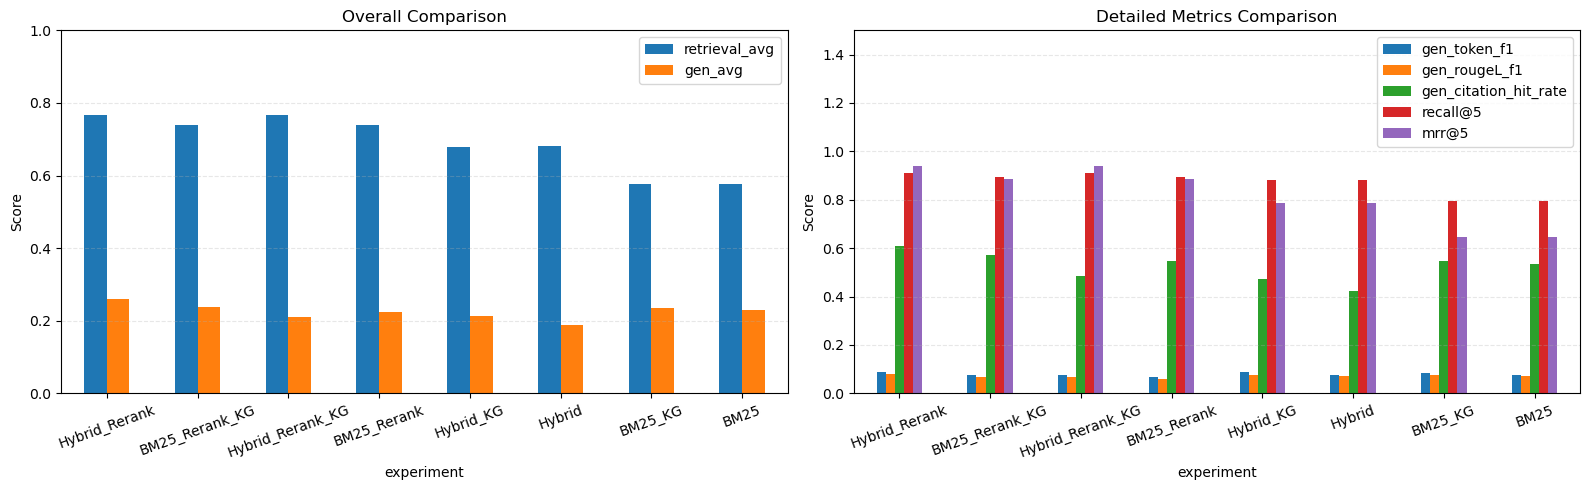


[CONCLUSION]
- Best current setting: Hybrid_Rerank
- Combined score: 0.5126  (retrieval_avg=0.7657, gen_avg=0.2596)
  gen_avg fields: token_f1, rougeL_f1, citation_hit_rate
- Rerank effect on best combined score: +0.0668 (best rerank vs best non-rerank)

[IMPROVEMENT SUGGESTIONS]
1. Improve first-stage recall before tuning rerank (rerank cannot recover missing relevant docs).
2. Ensure retrieved_doc_ids are populated and aligned with GT references/doc IDs.
3. If Gemini embedding quota is limited, run BM25-only baseline and compare after quota recovers.
4. Expand GT set beyond a single question to reduce metric variance and make conclusions robust.
5. For citation scoring, keep reference format consistent between GT and predicted citations.


In [93]:
import json
from pathlib import Path


def _safe(v):
    return float(v) if isinstance(v, (int, float)) else 0.0


def _load_json(path: Path):
    if path.exists():
        return json.loads(path.read_text(encoding="utf-8"))
    return None


def _collect_runs():
    runs = {}

    # Prefer ablation outputs when available
    ab_dir = ROOT / "outputs" / "ablation"
    if ab_dir.exists():
        for f in sorted(ab_dir.glob("eval_*.json")):
            name = f.stem.replace("eval_", "")
            obj = _load_json(f)
            if obj:
                runs[name] = obj

    # Fallback to baseline pair
    if not runs:
        if EVAL_HYBRID.exists():
            runs["Hybrid"] = _load_json(EVAL_HYBRID)
        if EVAL_HYBRID_RERANK.exists():
            runs["Hybrid_plus_Rerank"] = _load_json(EVAL_HYBRID_RERANK)

    return {k: v for k, v in runs.items() if v is not None}


runs = _collect_runs()
print("=" * 70)
print("Evaluation Conclusion")
print("=" * 70)

if not runs:
    print("[WARN] No evaluation files found. Run the evaluation cells first.")
else:
    # Build compact score table (retrieval avg + generation avg)
    summary = []
    for name, obj in runs.items():
        r = obj.get("retrieval", {})
        g = obj.get("generation", {})

        retrieval_avg = (_safe(r.get("recall@5")) + _safe(r.get("precision@5")) + _safe(r.get("ndcg@5")) + _safe(r.get("mrr@5")) + _safe(r.get("map@5"))) / 5.0
        # generation_avg is computed adaptively after the loop (see below)
        generation_avg = (_safe(g.get("exact_match")) + _safe(g.get("token_f1")) + _safe(g.get("rougeL_f1")) + _safe(g.get("citation_hit_rate"))) / 4.0

        summary.append({
            "experiment": name,
            "retrieval_avg": retrieval_avg,
            "gen_avg": generation_avg,
            "recall@5": _safe(r.get("recall@5")),
            "mrr@5": _safe(r.get("mrr@5")),
            "gen_exact_match": _safe(g.get("exact_match")),
            "gen_token_f1": _safe(g.get("token_f1")),
            "gen_rougeL_f1": _safe(g.get("rougeL_f1")),
            "gen_citation_hit_rate": _safe(g.get("citation_hit_rate")),
        })

    # Adaptive gen_avg: exclude citation_hit_rate when no experiment produced any
    # citations (structurally-zero values inflate the denominator and compress all
    # gen_avg scores equally, masking real differences in other generation metrics).
    _has_citation = any(s["gen_citation_hit_rate"] > 1e-9 for s in summary)
    # Adaptive gen_avg: exclude exact_match when it is zero for all experiments
    # (strict string equality rarely fires; including it compresses gen_avg without
    # adding discriminative signal).
    _has_exact_match = any(s["gen_exact_match"] > 1e-9 for s in summary)
    for s in summary:
        _gen_fields = []
        if _has_exact_match:
            _gen_fields.append(s["gen_exact_match"])
        _gen_fields += [s["gen_token_f1"], s["gen_rougeL_f1"]]
        if _has_citation:
            _gen_fields.append(s["gen_citation_hit_rate"])
        s["gen_avg"] = sum(_gen_fields) / len(_gen_fields)
        # Combined score: equal weight for retrieval and generation.
        # Retrieval is the RAG foundation — poor retrieval caps the generation ceiling.
        s["combined_score"] = 0.5 * s["retrieval_avg"] + 0.5 * s["gen_avg"]

    # Sort by combined_score (primary), gen_avg (secondary), retrieval_avg (tiebreaker)
    summary = sorted(summary, key=lambda x: (x["combined_score"], x["gen_avg"], x["retrieval_avg"]), reverse=True)

    if pd is not None:
        df_display = pd.DataFrame(summary)
        # Drop gen_exact_match column when it adds no signal (all zeros)
        if not _has_exact_match and "gen_exact_match" in df_display.columns:
            df_display = df_display.drop(columns=["gen_exact_match"])
        display(df_display)
    else:
        _display_rows = []
        for s in summary:
            row = dict(s)
            if not _has_exact_match:
                row.pop("gen_exact_match", None)
            _display_rows.append(row)
        print(json.dumps(_display_rows, indent=2, ensure_ascii=False))

    if pd is not None and summary:
        df_summary_plot = pd.DataFrame(summary).set_index("experiment")

        overall_cols = [c for c in ["retrieval_avg", "gen_avg"] if c in df_summary_plot.columns]
        detail_cols = [
            c for c in ["gen_token_f1", "gen_rougeL_f1", "gen_citation_hit_rate", "recall@5", "mrr@5"]
            if c in df_summary_plot.columns
        ]

        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        if overall_cols:
            df_summary_plot[overall_cols].plot(kind="bar", ax=axes[0], rot=20)
            axes[0].set_title("Overall Comparison")
            axes[0].set_ylabel("Score")
            axes[0].set_ylim(0, 1)
            axes[0].grid(axis="y", linestyle="--", alpha=0.3)

        if detail_cols:
            df_summary_plot[detail_cols].plot(kind="bar", ax=axes[1], rot=20)
            axes[1].set_title("Detailed Metrics Comparison")
            axes[1].set_ylabel("Score")
            axes[1].set_ylim(0, 1.5)
            axes[1].grid(axis="y", linestyle="--", alpha=0.3)

        plt.tight_layout()
        plt.show()
    else:
        print("No summary data available for plotting.")

    best = summary[0]

    print("\n[CONCLUSION]")
    print(f"- Best current setting: {best['experiment']}")
    print(f"- Combined score: {best['combined_score']:.4f}  (retrieval_avg={best['retrieval_avg']:.4f}, gen_avg={best['gen_avg']:.4f})")
    _gen_avg_fields = (
        (["exact_match"] if _has_exact_match else [])
        + ["token_f1", "rougeL_f1"]
        + (["citation_hit_rate"] if _has_citation else [])
    )
    print(f"  gen_avg fields: {', '.join(_gen_avg_fields)}")

    all_retrieval_zero = all(abs(s["retrieval_avg"]) < 1e-12 for s in summary)
    rerank_rows = [s for s in summary if "rerank" in s["experiment"].lower()]
    non_rerank_rows = [s for s in summary if "rerank" not in s["experiment"].lower()]

    if all_retrieval_zero:
        print("- Retrieval metrics are all near zero across runs: rerank has no strong candidate set to improve.")

    if rerank_rows and non_rerank_rows:
        best_rerank = max(rerank_rows, key=lambda x: x["combined_score"])
        best_non_rerank = max(non_rerank_rows, key=lambda x: x["combined_score"])
        delta = best_rerank["combined_score"] - best_non_rerank["combined_score"]
        print(f"- Rerank effect on best combined score: {delta:+.4f} (best rerank vs best non-rerank)")

    print("\n[IMPROVEMENT SUGGESTIONS]")
    print("1. Improve first-stage recall before tuning rerank (rerank cannot recover missing relevant docs).")
    print("2. Ensure retrieved_doc_ids are populated and aligned with GT references/doc IDs.")
    print("3. If Gemini embedding quota is limited, run BM25-only baseline and compare after quota recovers.")
    print("4. Expand GT set beyond a single question to reduce metric variance and make conclusions robust.")
    print("5. For citation scoring, keep reference format consistent between GT and predicted citations.")


## 7) Reproducibility artifacts

- `outputs/preds_hybrid.jsonl`
- `outputs/preds_hybrid_rerank.jsonl`
- `outputs/eval_hybrid.json`
- `outputs/eval_hybrid_rerank.json`
- `outputs/run_snapshot_YYYYmmdd_HHMMSS.json` (auto-generated by benchmark script)